<a href="https://colab.research.google.com/github/sileysa/Semester_5/blob/main/JS05/JS05_Tugas1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nomor 1 — Membuat model klasifikasi KNN

## 1. Import library

In [20]:
# ============================================
# TUGAS LAB 1 - KNN KLASIFIKASI SUARA
# NOMOR 1
# ============================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Membaca dataset

In [21]:
# Membaca dataset
df = pd.read_csv('/content/voice.csv')

# Melihat ukuran dataset
print("Ukuran dataset:", df.shape)

# Menampilkan 5 data pertama
display(df.head())

Ukuran dataset: (3168, 21)


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


## 3. Memisahkan fitur dan target

In [22]:
# Memisahkan fitur dan target
X = df.drop(columns=['label'])

# Mengubah label menjadi angka
# female = 0
# male   = 1
y = df['label'].map({
    'female': 0,
    'male': 1
})

print("Jumlah fitur:", X.shape[1])
print("Nama fitur:")
print(X.columns.tolist())

Jumlah fitur: 20
Nama fitur:
['meanfreq', 'sd', 'median', 'Q25', 'Q75', 'IQR', 'skew', 'kurt', 'sp.ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun', 'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx']


## 4. Membagi data training dan testing

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing :", len(X_test))

Jumlah data training: 2534
Jumlah data testing : 634


## 5. Membuat model KNN

In [24]:
# Model KNN
model_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=3))
])

# Training model
model_knn.fit(X_train, y_train)

# Prediksi data testing
y_pred = model_knn.predict(X_test)

# Menghitung akurasi
accuracy = accuracy_score(y_test, y_pred)

print("Akurasi KNN:", accuracy)
print("Akurasi (%):", accuracy * 100)

Akurasi KNN: 0.9763406940063092
Akurasi (%): 97.63406940063092


# Nomor 2 — Mencari fitur yang paling optimal

## 2.1 Menghitung tingkat informasi setiap fitur

In [25]:
# ============================================
# NOMOR 2 - SELEKSI FITUR
# ============================================

from sklearn.feature_selection import mutual_info_classif

# Menghitung Mutual Information
mi = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

# Membuat tabel hasil
mi_df = pd.DataFrame({
    'Fitur': X.columns,
    'Mutual Information': mi
})

# Mengurutkan dari terbesar ke terkecil
mi_df = mi_df.sort_values(
    by='Mutual Information',
    ascending=False
)

display(mi_df)

,Fitur,Mutual Information
12,meanfun,0.555423
5,IQR,0.449243
3,Q25,0.406964
1,sd,0.302449
10,mode,0.177453
8,sp.ent,0.170729
9,sfm,0.126971
0,meanfreq,0.116538
11,centroid,0.116538
16,mindom,0.095199


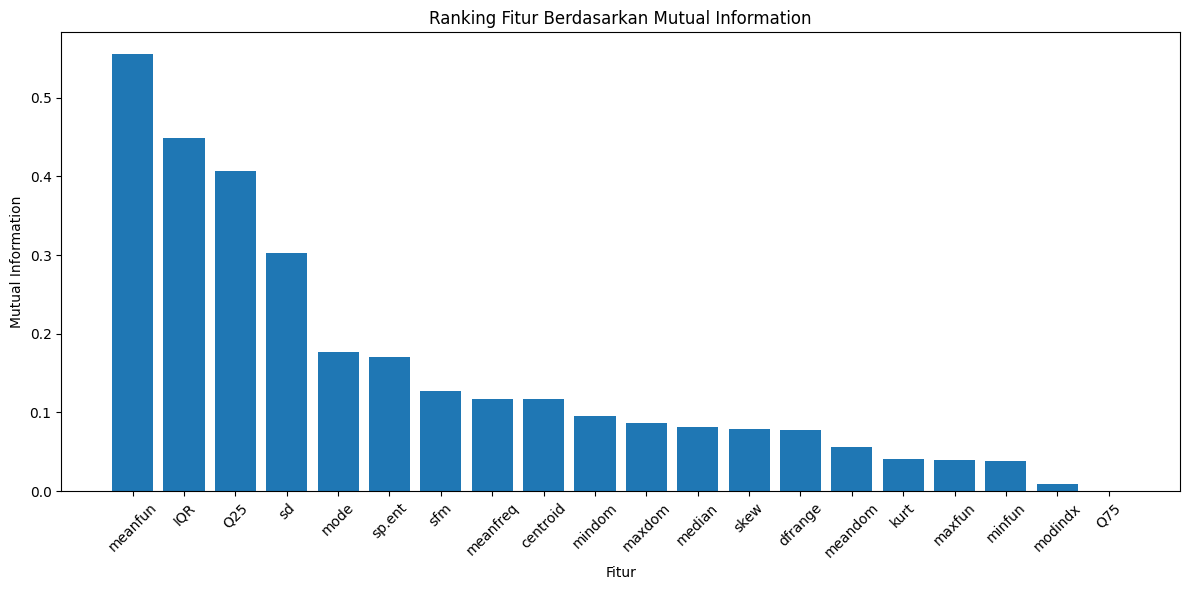

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    mi_df['Fitur'],
    mi_df['Mutual Information']
)

plt.xticks(rotation=45)
plt.xlabel('Fitur')
plt.ylabel('Mutual Information')
plt.title('Ranking Fitur Berdasarkan Mutual Information')

plt.tight_layout()
plt.show()

## 2.2 Menguji jumlah fitur

In [27]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

hasil_fitur = []

# Mencoba jumlah fitur dari 1 sampai 20
for jumlah in range(1, 21):

    # Mengambil sejumlah fitur teratas
    fitur = mi_df.head(jumlah)['Fitur'].tolist()

    # Membuat model KNN
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=3))
    ])

    # Cross-validation
    skor = cross_val_score(
        model,
        X_train[fitur],
        y_train,
        cv=cv,
        scoring='accuracy'
    )

    # Menyimpan hasil
    hasil_fitur.append({
        'Jumlah Fitur': jumlah,
        'Akurasi': skor.mean()
    })

hasil_fitur = pd.DataFrame(hasil_fitur)

display(hasil_fitur)

,Jumlah Fitur,Akurasi
0,1,0.938831
1,2,0.963297
2,3,0.969216
3,4,0.977109
4,5,0.979082
5,6,0.975927
6,7,0.977504
7,8,0.975924
8,9,0.975528
9,10,0.973554


## 2.3 Membuat grafik fitur

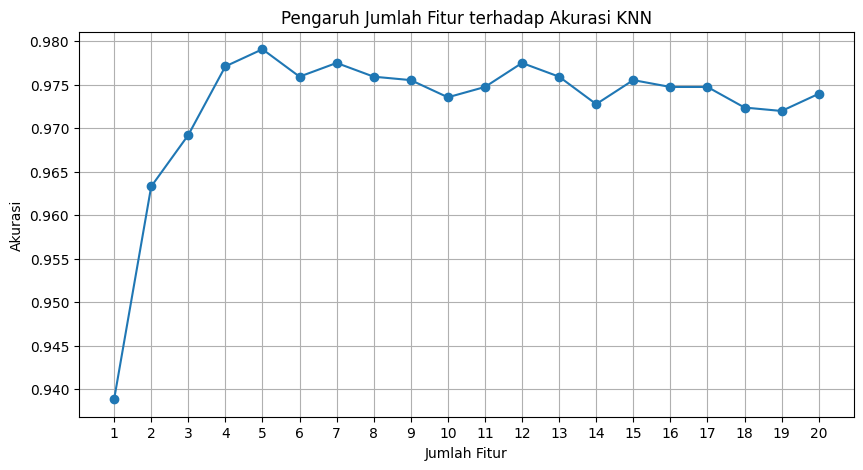

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(
    hasil_fitur['Jumlah Fitur'],
    hasil_fitur['Akurasi'],
    marker='o'
)

plt.xlabel('Jumlah Fitur')
plt.ylabel('Akurasi')
plt.title('Pengaruh Jumlah Fitur terhadap Akurasi KNN')

plt.xticks(range(1, 21))
plt.grid(True)

plt.show()

## 2.4 Menampilkan fitur terbaik

In [29]:
# Mencari jumlah fitur dengan akurasi tertinggi
hasil_terbaik = hasil_fitur.loc[
    hasil_fitur['Akurasi'].idxmax()
]

jumlah_fitur_terbaik = int(
    hasil_terbaik['Jumlah Fitur']
)

fitur_terbaik = mi_df.head(
    jumlah_fitur_terbaik
)['Fitur'].tolist()

print("Jumlah fitur terbaik:", jumlah_fitur_terbaik)
print("Fitur terbaik:")
print(fitur_terbaik)

print(
    "Akurasi terbaik:",
    hasil_terbaik['Akurasi']
)

Jumlah fitur terbaik: 5
Fitur terbaik:
['meanfun', 'IQR', 'Q25', 'sd', 'mode']
Akurasi terbaik: 0.9790817877774399


# Nomor 3 — Mencari nilai k terbaik

In [30]:
fitur_terbaik = [
    'meanfun',
    'IQR',
    'Q25',
    'sd',
    'mode'
]

## 3.1 Percobaan k = 1 sampai 20

In [31]:
# ============================================
# NOMOR 3 - MENCARI NILAI k TERBAIK
# ============================================

hasil_k = []

# Mencoba nilai k dari 1 sampai 20
for k in range(1, 21):

    # Membuat model KNN
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    # Cross-validation
    skor = cross_val_score(
        model,
        X_train[fitur_terbaik],
        y_train,
        cv=cv,
        scoring='accuracy'
    )

    hasil_k.append({
        'k': k,
        'Akurasi': skor.mean()
    })

hasil_k = pd.DataFrame(hasil_k)

display(hasil_k)

,k,Akurasi
0,1,0.975531
1,2,0.977109
2,3,0.979082
3,4,0.976320
4,5,0.977109
5,6,0.976319
6,7,0.973952
7,8,0.974739
8,9,0.973162
9,10,0.973162


## 3.2 Membuat grafik analisis k

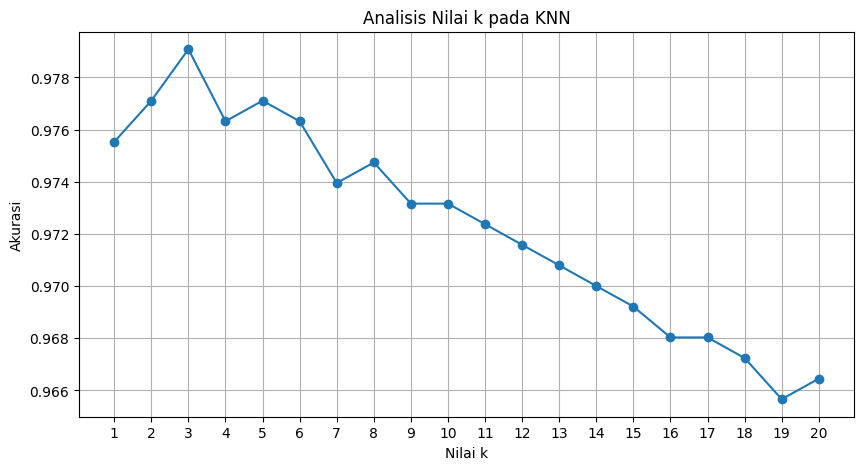

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(
    hasil_k['k'],
    hasil_k['Akurasi'],
    marker='o'
)

plt.xlabel('Nilai k')
plt.ylabel('Akurasi')
plt.title('Analisis Nilai k pada KNN')

plt.xticks(range(1, 21))
plt.grid(True)

plt.show()

## 3.3 Mencari k terbaik secara otomatis

In [33]:
# Mencari k dengan akurasi tertinggi
k_terbaik = hasil_k.loc[
    hasil_k['Akurasi'].idxmax()
]

print("k terbaik:", int(k_terbaik['k']))
print("Akurasi terbaik:", k_terbaik['Akurasi'])
print(
    "Akurasi (%):",
    k_terbaik['Akurasi'] * 100
)

k terbaik: 3
Akurasi terbaik: 0.9790817877774399
Akurasi (%): 97.908178777744


## 3.4 Membuat model final

In [34]:
# Model final
model_final = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=3))
])

# Training
model_final.fit(
    X_train[fitur_terbaik],
    y_train
)

# Prediksi
y_pred_final = model_final.predict(
    X_test[fitur_terbaik]
)

# Akurasi
akurasi_final = accuracy_score(
    y_test,
    y_pred_final
)

print("====================================")
print("HASIL MODEL FINAL")
print("====================================")
print("Fitur yang digunakan:", fitur_terbaik)
print("Nilai k:", 3)
print("Akurasi testing:", akurasi_final)
print("Akurasi testing (%):", akurasi_final * 100)

HASIL MODEL FINAL
Fitur yang digunakan: ['meanfun', 'IQR', 'Q25', 'sd', 'mode']
Nilai k: 3
Akurasi testing: 0.9826498422712934
Akurasi testing (%): 98.26498422712933
